In [49]:
!pip install wordcloud

Defaulting to user installation because normal site-packages is not writeable


In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

Data: https://www.kaggle.com/datasets/harshlakhani2005/ai-tool-directory-2026-10000-real-world-tools

In [3]:
path = r"C:\Users\Rudra\Desktop\kaggle\ai-tools\AI_Landscape_10k_Tools_2026.csv"

In [ ]:
df = pd.read_csv(path)

,AI_Name,Developer,Release_Year,Intelligence_Type,Primary_Domain,Key_Functionality,Pricing_Model,API_Availability,Context_Window,Accessibility,Popularity_Votes,Website_URL
0,Scrip Ai,Scrip Labs,2024,Generative Video,Video,Free AI writer for creating viral short video ...,Free,Yes (GraphQL),32k tokens,SaaS Platform,15592,https://scripai.com
1,Quickads,Smart Soft,2024,Computer Vision / Generative Art,Image/Design,AI ad generator for creating image and video a...,Open Source,Yes (GraphQL),N/A (Task Specific),Mobile App (iOS/Android),43696,https://www.quickads.ai/
2,Wonderchat,Wonderchat Inc.,2023,Conversational AI,General/Other,AI Chatbot builder to create custom ChatGPT ch...,Open Source,Yes (GraphQL),N/A (Task Specific),Browser Extension,39722,https://wonderchat.io
3,Creatosaurus,Smart Intelligence,2022,Autonomous Agent,Automation,All-in-one creative and marketing platform for...,Subscription,Enterprise Only,32k tokens,Web App,39543,https://www.creatosaurus.io
4,Blobr,Deep Systems,2024,Autonomous Agent,Automation,AI agents to optimize Google Ads spending 24/7.,Free,Private Beta,128k tokens,Mobile App (iOS/Android),26018,https://blobr.io
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,Undetectio,Neural AI,2022,Large Language Model (LLM),General/Other,AI paraphraser to make AI content undetectable...,Usage-Based,Yes (GraphQL),32k tokens,Desktop (Win/Mac),146,https://www.undetectio.com
9996,Human Or Ai,Deep Creative,2022,Large Language Model (LLM),Audio,AI Humanizer tool to make AI text sound natura...,Freemium,Enterprise Only,128k tokens,API / Developer Tools,26548,https://humanorai.io
9997,Ai Bypass,Ai Soft,2022,Large Language Model (LLM),Writing,AI Bypass is an AI tool to bypass AI detection...,Usage-Based,Waitlist,128k tokens,Desktop (Win/Mac),21962,https://aibypass.com
9998,Academichelp Paraphraser,Global Robotics,2024,Multimodal Generative AI,General/Other,"AI-powered tools for writing, paraphrasing, pl...",Free,Private Beta,N/A (Task Specific),Desktop (Win/Mac),30896,https://hub.academichelp.net/


In [ ]:
df

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   AI_Name            10000 non-null  object
 1   Developer          10000 non-null  object
 2   Release_Year       10000 non-null  int64 
 3   Intelligence_Type  10000 non-null  object
 4   Primary_Domain     10000 non-null  object
 5   Key_Functionality  10000 non-null  object
 6   Pricing_Model      10000 non-null  object
 7   API_Availability   10000 non-null  object
 8   Context_Window     10000 non-null  object
 9   Accessibility      10000 non-null  object
 10  Popularity_Votes   10000 non-null  int64 
 11  Website_URL        10000 non-null  object
dtypes: int64(2), object(10)
memory usage: 937.6+ KB


In [38]:
df.sample(3)

,AI_Name,Developer,Release_Year,Intelligence_Type,Primary_Domain,Key_Functionality,Pricing_Model,API_Availability,Context_Window,Accessibility,Popularity_Votes,Website_URL
4242,Pippinshelp,Flow Technologies,2023,Multimodal Generative AI,Research/Search,A GPT-powered Chrome extension for easier job ...,Pay-as-you-go,Yes (REST),200k tokens,SaaS Platform,9725,https://pippinshelp.com
5966,Infiheal,Infiheal Intelligence,2024,Multimodal Generative AI,General/Other,AI-powered mental health support and therapy b...,Usage-Based,Yes (GraphQL),8k tokens,API / Developer Tools,9140,https://www.infiheal.com
428,Make Ad,Flow AI,2024,Large Language Model (LLM),Writing,AI platform to create high-converting product ...,Subscription,Enterprise Only,128k tokens,Mobile App (iOS/Android),43606,https://make.ad


In [17]:
for col in df.columns:
    print(f"{col} -> {df[col].nunique()}")

AI_Name -> 10000
Developer -> 2889
Release_Year -> 5
Intelligence_Type -> 8
Primary_Domain -> 8
Key_Functionality -> 9968
Pricing_Model -> 6
API_Availability -> 6
Context_Window -> 6
Accessibility -> 6
Popularity_Votes -> 9062
Website_URL -> 9931


In [19]:
df.columns

Index(['AI_Name', 'Developer', 'Release_Year', 'Intelligence_Type',
       'Primary_Domain', 'Key_Functionality', 'Pricing_Model',
       'API_Availability', 'Context_Window', 'Accessibility',
       'Popularity_Votes', 'Website_URL'],
      dtype='object')

# word Cloud

In [51]:
text = " ".join(df["Key_Functionality"])
text

'Free AI writer for creating viral short video scripts and AI content. AI ad generator for creating image and video ads quickly and efficiently. AI Chatbot builder to create custom ChatGPT chatbots from website links or PDFs. All-in-one creative and marketing platform for streamlined workflow and scalable storytelling. AI agents to optimize Google Ads spending 24/7. AI ad generator for faster ad creation and improved performance. Free AI copy generator using GPT-4 to create high-converting ad copy. Marpipe uses AI to optimize and control Dynamic Product Ads for brands. AI-powered platform to scale and optimize ad campaigns with creative automation and brand management. Open-source AI coding assistant for VS Code, enhancing coding efficiency and automation. AI-powered Google Ads copy generator for efficient and effective ad creation. Adbot automates and optimizes online advertising campaigns using AI for small businesses. AI tool for generating compliant and high-converting Facebook ad 

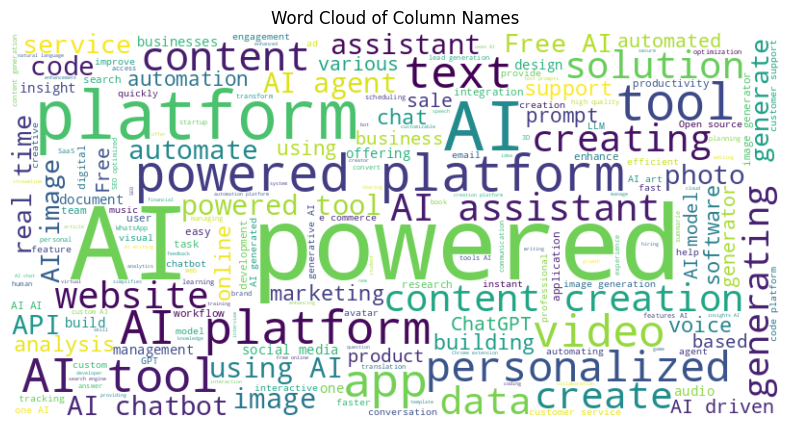

In [ ]:
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white",
    colormap="viridis"
).generate(text)

In [ ]:
plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Key_Functionality")
plt.show()

In [20]:
un_list = [ 'Intelligence_Type','Primary_Domain', 'Pricing_Model','API_Availability', 'Context_Window']

# Release Year and Votes %age

In [77]:
def plot_pie(col):
    count_df = df.groupby(col)["Release_Year"].count().reset_index()
    vote_df = df.groupby(col)["Popularity_Votes"].mean().reset_index()
    
    fig, ax = plt.subplots(1, 2, figsize=(12, 10))
    
    ax[0].pie(
        count_df["Release_Year"],
        labels=vote_df[col],
        autopct="%2.1f%%",
    )
    ax[0].set_title(f"{col} Year wise")
    
    ax[1].pie(
        vote_df["Popularity_Votes"],
        labels=vote_df[col],
        autopct="%2.1f%%",
    )
    
    plt.tight_layout()
    plt.show()

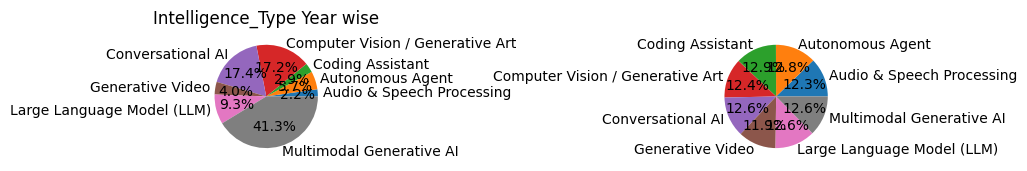

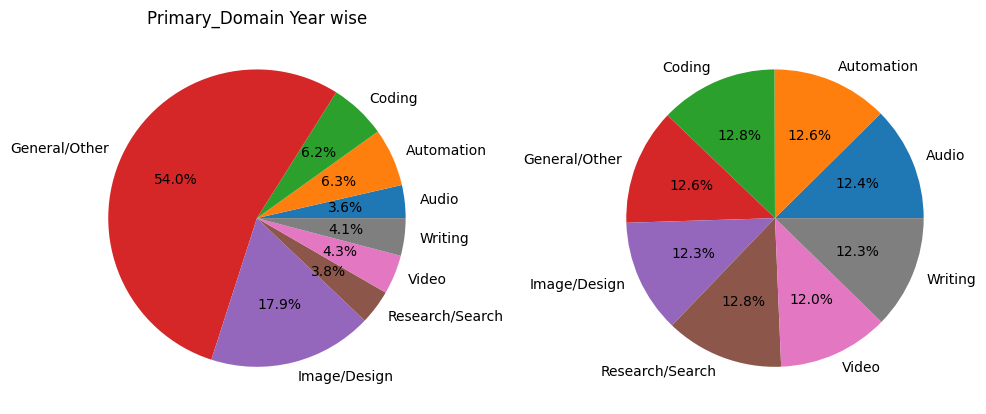

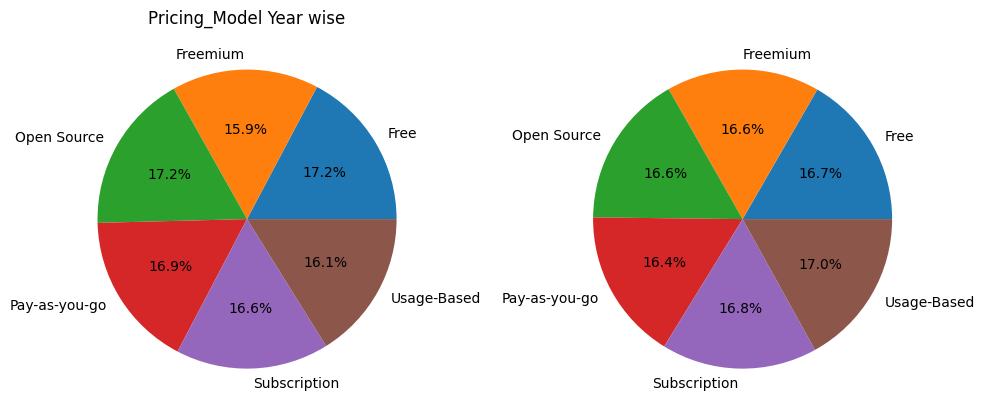

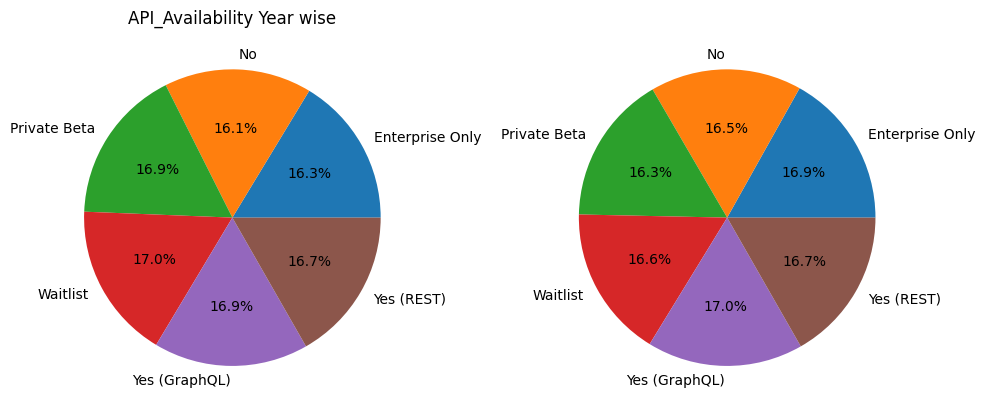

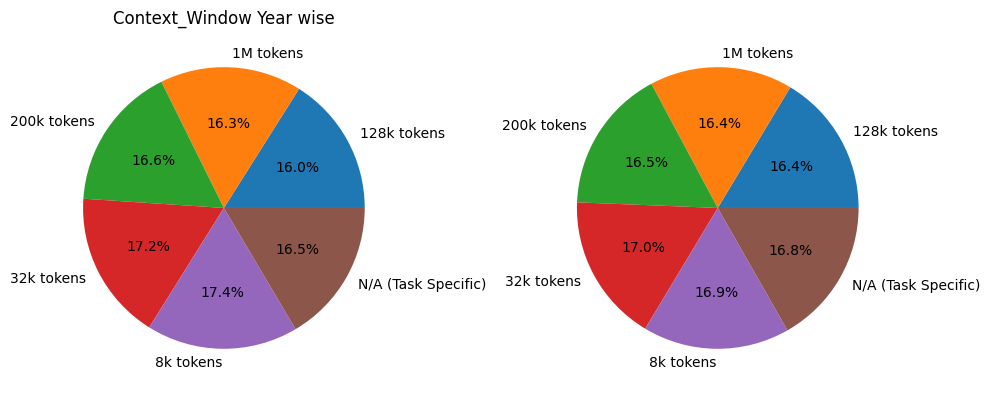

In [76]:
for col in un_list:
    plot_pie(col)